# Mautkosten-Szenarien 2025–2030
## Wettbewerbsanalyse: Deutschland, Polen, Tschechien

Dieses Notebook modelliert die Entwicklung der LKW-Mautkosten in drei Ländern bis 2030
und leitet daraus Wettbewerbsimplikationen für sächsische Logistiker ab.

---

## 1. Konzeptioneller Rahmen

Die Gesamtkosten pro km eines LKW-Transports setzen sich aus drei Hauptkomponenten zusammen:

$$
K_{gesamt}(t) = K_{Lohn}(t) + K_{Diesel}(t) + K_{Maut}(t)
$$

Dieses Notebook fokussiert auf $K_{Maut}(t)$ und modelliert deren Entwicklung bis 2030
als Funktion zweier Treiber:

### 1.1 Treiber 1: CO₂-Klassenautomatik

Die EU-Eurovignetten-Richtlinie schreibt vor, dass die CO₂-Referenzwerte zur Klasseneinstufung
jährlich abgesenkt werden:

$$
r_{CO2}(t) = \begin{cases}
0.025 & \text{für } t \leq 2026 \\
0.030 & \text{für } t > 2026
\end{cases}
$$

Ohne neue politische Entscheidungen rutschen Diesel-LKW dadurch automatisch in teurere Klassen.
Der Klassendrift-Aufschlag wächst kumulativ:

$$
\Delta K_{Klasse}(t) = K_{Maut,0} \cdot \left[\prod_{s=2026}^{t}(1 + r_{CO2}(s)) - 1\right]
$$

### 1.2 Treiber 2: ETS2 (ab 2027)

Das neue EU-Emissionshandelssystem ETS2 startet 2027 und bepreist CO₂ im Straßenverkehr
über Auktionen. Der resultierende Mautaufschlag pro km berechnet sich als:

$$
\Delta K_{ETS2}(t) = \frac{E_{LKW} \cdot P_{CO2,ETS2}(t)}{100}
$$

wobei:
- $E_{LKW}$ = CO₂-Emissionen des LKW in g/km (EURO VI Diesel ≈ 600–750 g/km)
- $P_{CO2,ETS2}(t)$ = ETS2-Preis in €/Tonne CO₂

Der ETS2-Preis ist der zentrale Unsicherheitsparameter. Laut EWI Köln (2025):

| Szenario | ETS2-Preis 2030 |
|---|---|
| Optimistisch | 60 €/t |
| Basis | 100–120 €/t |
| Pessimistisch | 200 €/t |

### 1.3 Gesamtmaut Deutschland

$$
K_{Maut,DE}(t) = K_{Maut,DE,0} + \Delta K_{Klasse}(t) + \Delta K_{ETS2}(t) + \Delta K_{Weg}(t)
$$

wobei $\Delta K_{Weg}(t)$ die Erhöhung durch die neue Wegekostenrechnung 2028–2032 abbildet.

### 1.4 Wettbewerbslücke

Der Maut-Gap zwischen Deutschland und Polen/Tschechien:

$$
\text{Gap}(t) = K_{Maut,DE}(t) - K_{Maut,PL/CZ}(t)
$$

Für sächsische Logistiker ist dieser Gap besonders relevant, da ihre Routen
strukturell höhere DE-Mautanteile aufweisen als westdeutsche Wettbewerber.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# ABHÄNGIGKEITEN
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})
print('Bibliotheken geladen.')

Bibliotheken geladen.


## 2. Parameter

Alle Annahmen sind hier zentral dokumentiert und können einfach angepasst werden.

**Quellen:**
- Mautsätze DE: BALM / BMV (https://www.bmv.de)
- Mautsätze PL: e-TOLL (https://etoll.gov.pl/de)
- Mautsätze CZ: myto.gov.cz (https://myto.gov.cz/de)
- ETS2-Szenarien: EWI Köln (2025), Electrive (2025)
- CO₂-Klassenautomatik: EU-Richtlinie 2022/362, DKV Mobility

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# PARAMETER – hier anpassen
# ─────────────────────────────────────────────────────────────────────────────

# --- Zeitraum ---
JAHRE = list(range(2021, 2031))

# --- Historische / aktuelle Mautsätze in ct/km ---
# Referenzfahrzeug: EURO VI Diesel, 40t, 5 Achsen
# Quelle: BALM (DE), e-TOLL (PL), myto.gov.cz (CZ)
MAUT_HISTORISCH = {
    # Jahr: (DE, PL, CZ) in ct/km
    2021: (19.0, 11.0, 14.0),
    2022: (20.0, 12.0, 14.5),
    2023: (22.0, 13.0, 15.0),
    2024: (47.0, 16.0, 18.0),  # DE: CO2-Schock Dez. 2023 + Ausweitung Juli 2024
    2025: (50.0, 17.0, 19.0),  # Aktuelle Werte
}

# --- CO2-Klassenautomatik (EU-Richtlinie 2022/362) ---
# Jährliche Absenkung der Referenzwerte → LKW rutschen in teurere Klassen
DRIFT_BIS_2026   = 0.025   # 2.5% pro Jahr bis 2026
DRIFT_AB_2027    = 0.030   # 3.0% pro Jahr ab 2027

# Anteil der Maut, der durch Klassenautomatik betroffen ist (CO2-Teilsatz)
# CO2-Teilsatz DE ≈ 16.2 ct/km von ~50 ct/km gesamt → ~32%
ANTEIL_CO2_TEILSATZ_DE = 0.32

# --- ETS2 (ab 2027) ---
# CO2-Emissionen EURO VI Diesel in g/km (typischer 40t Sattelzug)
EMISSIONEN_EURO6_G_KM = 680.0  # g CO2/km

# ETS2-Preisszenarien in €/Tonne CO2 für 2027–2030
# Quelle: EWI Köln (2025), Schätzungen 48–350 €/t
ETS2_SZENARIEN = {
    'optimistisch': {2027: 45,  2028: 55,  2029: 58,  2030: 60},
    'basis':        {2027: 90,  2028: 100, 2029: 110, 2030: 120},
    'pessimistisch':{2027: 130, 2028: 160, 2029: 180, 2030: 200},
}

# ETS2 gilt EU-weit → auch PL und CZ betroffen, aber mit Verzögerung
# PL und CZ setzen ETS2 strukturell langsamer um (politischer Widerstand)
ETS2_FAKTOR_PL  = 0.5   # PL nutzt ~50% des ETS2-Effekts als Mauterhöhung
ETS2_FAKTOR_CZ  = 0.6   # CZ etwas schneller als PL

# --- Neue Wegekostenrechnung DE 2028–2032 ---
# Geschätzter Aufschlag durch höhere Infrastruktur- und Lärmkosten
WEGEKOSTEN_AUFSCHLAG_2028 = 2.5  # ct/km zusätzlich ab 2028

# --- Polen: jährliche Basiserhöhungen (Inflation, CO2-Pflicht) ---
ERHOEHUNG_PL_JAEHRLICH = 0.08   # ~8% p.a. (historisch 2023–2025)

# --- Tschechien: jährliche Basiserhöhungen ---
ERHOEHUNG_CZ_JAEHRLICH = 0.07   # ~7% p.a.

print('Parameter gesetzt.')
print(f'  DE Maut 2025:  {MAUT_HISTORISCH[2025][0]:.1f} ct/km')
print(f'  PL Maut 2025:  {MAUT_HISTORISCH[2025][1]:.1f} ct/km')
print(f'  CZ Maut 2025:  {MAUT_HISTORISCH[2025][2]:.1f} ct/km')
print(f'  Gap DE–PL:     {MAUT_HISTORISCH[2025][0]-MAUT_HISTORISCH[2025][1]:.1f} ct/km')

Parameter gesetzt.
  DE Maut 2025:  50.0 ct/km
  PL Maut 2025:  17.0 ct/km
  CZ Maut 2025:  19.0 ct/km
  Gap DE–PL:     33.0 ct/km


## 3. Modell: Mautentwicklung 2025–2030

Das Modell berechnet für jedes Szenario (optimistisch / Basis / pessimistisch)
die Mautkosten in allen drei Ländern.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# HILFSFUNKTIONEN
# ─────────────────────────────────────────────────────────────────────────────

def co2_klassendrift(maut_basis_ct, anteil_co2, jahr):
    """
    Berechnet den kumulativen Aufschlag durch CO2-Klassenautomatik.
    Drift wirkt ab 2026 auf den CO2-Teilsatz der Maut.
    """
    if jahr <= 2025:
        return 0.0
    co2_basis = maut_basis_ct * anteil_co2
    faktor = 1.0
    for y in range(2026, jahr + 1):
        rate = DRIFT_BIS_2026 if y <= 2026 else DRIFT_AB_2027
        faktor *= (1 + rate)
    return co2_basis * (faktor - 1)


def ets2_aufschlag_ct_km(jahr, szenario, faktor=1.0):
    """
    Berechnet den ETS2-bedingten Mautaufschlag in ct/km.
    Formel: (Emissionen_g/km * Preis_€/tCO2) / 1_000_000 * 100
             = Emissionen_g/km * Preis / 10_000
    """
    if jahr < 2027:
        return 0.0
    preis = ETS2_SZENARIEN[szenario].get(jahr, 0)
    aufschlag = (EMISSIONEN_EURO6_G_KM * preis) / 10_000
    return aufschlag * faktor


def maut_de(jahr, szenario):
    """Maut Deutschland in ct/km."""
    if jahr in MAUT_HISTORISCH:
        return MAUT_HISTORISCH[jahr][0]
    basis = MAUT_HISTORISCH[2025][0]
    drift  = co2_klassendrift(basis, ANTEIL_CO2_TEILSATZ_DE, jahr)
    ets2   = ets2_aufschlag_ct_km(jahr, szenario, faktor=1.0)
    weg    = WEGEKOSTEN_AUFSCHLAG_2028 if jahr >= 2028 else 0.0
    return basis + drift + ets2 + weg


def maut_pl(jahr, szenario):
    """Maut Polen in ct/km."""
    if jahr in MAUT_HISTORISCH:
        return MAUT_HISTORISCH[jahr][1]
    basis = MAUT_HISTORISCH[2025][1]
    # Jährliche Basiserhöhung
    n_jahre = jahr - 2025
    proj = basis * (1 + ERHOEHUNG_PL_JAEHRLICH) ** n_jahre
    # ETS2-Effekt (verzögert und gedämpft)
    ets2 = ets2_aufschlag_ct_km(jahr, szenario, faktor=ETS2_FAKTOR_PL)
    return proj + ets2


def maut_cz(jahr, szenario):
    """Maut Tschechien in ct/km."""
    if jahr in MAUT_HISTORISCH:
        return MAUT_HISTORISCH[jahr][2]
    basis = MAUT_HISTORISCH[2025][2]
    n_jahre = jahr - 2025
    proj = basis * (1 + ERHOEHUNG_CZ_JAEHRLICH) ** n_jahre
    ets2 = ets2_aufschlag_ct_km(jahr, szenario, faktor=ETS2_FAKTOR_CZ)
    return proj + ets2


# ─────────────────────────────────────────────────────────────────────────────
# ERGEBNISSE BERECHNEN
# ─────────────────────────────────────────────────────────────────────────────
rows = []
for szenario in ['optimistisch', 'basis', 'pessimistisch']:
    for j in JAHRE:
        de = maut_de(j, szenario)
        pl = maut_pl(j, szenario)
        cz = maut_cz(j, szenario)
        rows.append({
            'Jahr':       j,
            'Szenario':   szenario,
            'DE (ct/km)': round(de, 1),
            'PL (ct/km)': round(pl, 1),
            'CZ (ct/km)': round(cz, 1),
            'Gap DE-PL':  round(de - pl, 1),
            'Gap DE-CZ':  round(de - cz, 1),
        })

df = pd.DataFrame(rows)

# Pivottabelle für Übersicht
pivot = df[df['Szenario'] == 'basis'][['Jahr','DE (ct/km)','PL (ct/km)','CZ (ct/km)','Gap DE-PL']]
print('Basis-Szenario:')
print(pivot.to_string(index=False))

Basis-Szenario:
 Jahr  DE (ct/km)  PL (ct/km)  CZ (ct/km)  Gap DE-PL
 2021        19.0        11.0        14.0        8.0
 2022        20.0        12.0        14.5        8.0
 2023        22.0        13.0        15.0        9.0
 2024        47.0        16.0        18.0       31.0
 2025        50.0        17.0        19.0       33.0
 2026        50.4        18.4        20.3       32.0
 2027        57.0        22.9        25.4       34.1
 2028        60.7        24.8        27.4       35.9
 2029        61.9        26.9        29.4       35.0
 2030        63.1        29.1        31.5       34.1


## 4. Visualisierungen

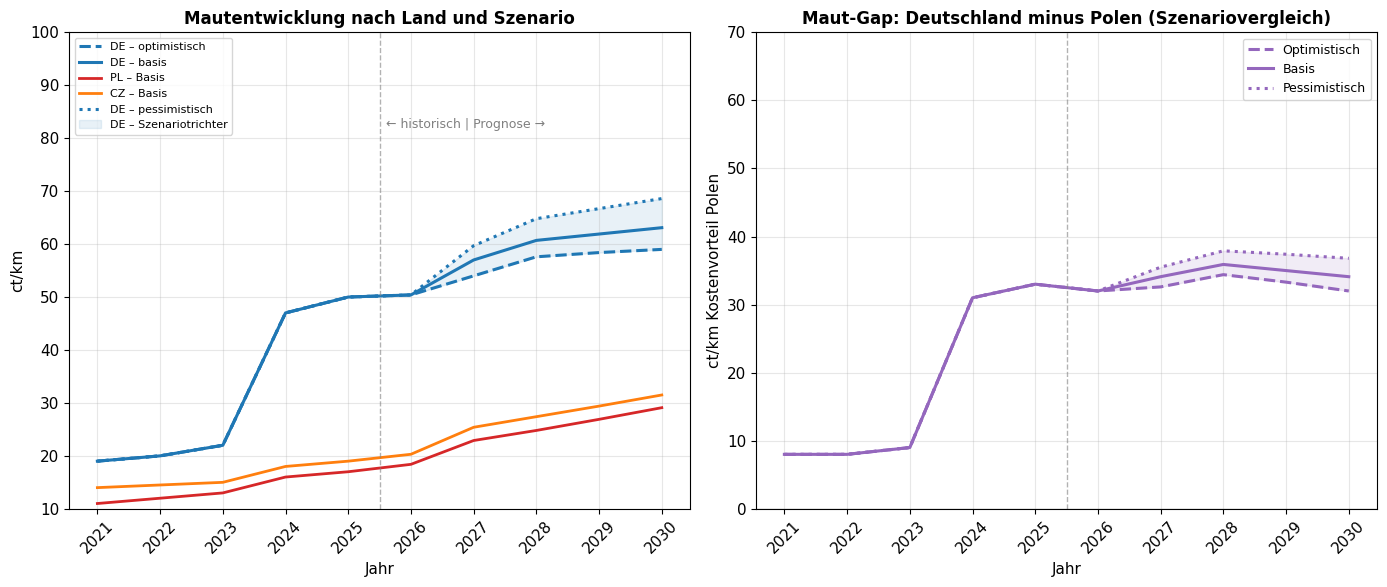

Abbildung 1 gespeichert.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# ABBILDUNG 1: Mautentwicklung mit Szenariotrichter (Deutschland)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

farben = {'DE': '#1f77b4', 'PL': '#d62728', 'CZ': '#ff7f0e'}
linien = {'optimistisch': '--', 'basis': '-', 'pessimistisch': ':'}

ax1 = axes[0]
ax1.set_title('Mautentwicklung nach Land und Szenario', fontsize=12, fontweight='bold')

for szenario, stil in linien.items():
    sub = df[df['Szenario'] == szenario]
    ax1.plot(sub['Jahr'], sub['DE (ct/km)'], color=farben['DE'],
             linestyle=stil, linewidth=2.2, label=f'DE – {szenario}')
    if szenario == 'basis':
        ax1.plot(sub['Jahr'], sub['PL (ct/km)'], color=farben['PL'],
                 linestyle='-', linewidth=2, label='PL – Basis')
        ax1.plot(sub['Jahr'], sub['CZ (ct/km)'], color=farben['CZ'],
                 linestyle='-', linewidth=2, label='CZ – Basis')

# Szenariotrichter DE als Fläche
opt_de  = df[df['Szenario']=='optimistisch']['DE (ct/km)'].values
pess_de = df[df['Szenario']=='pessimistisch']['DE (ct/km)'].values
ax1.fill_between(JAHRE, opt_de, pess_de, color=farben['DE'], alpha=0.10,
                 label='DE – Szenariotrichter')

# Trennlinie: historisch vs. Prognose
ax1.axvline(x=2025.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.text(2025.6, 82, '← historisch | Prognose →', fontsize=9, color='gray')

ax1.set_xlabel('Jahr')
ax1.set_ylabel('ct/km')
ax1.set_ylim(10, 100)
ax1.legend(fontsize=8, loc='upper left')
ax1.set_xticks(JAHRE)
ax1.tick_params(axis='x', rotation=45)

# ─────────────────────────────────────────────────────────────────────────────
# ABBILDUNG 2: Wettbewerbslücke (Gap DE – PL)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_title('Maut-Gap: Deutschland minus Polen (Szenariovergleich)', fontsize=12, fontweight='bold')

for szenario, stil in linien.items():
    sub = df[df['Szenario'] == szenario]
    ax2.plot(sub['Jahr'], sub['Gap DE-PL'], color='#9467bd',
             linestyle=stil, linewidth=2.2, label=szenario.capitalize())

opt_gap  = df[df['Szenario']=='optimistisch']['Gap DE-PL'].values
pess_gap = df[df['Szenario']=='pessimistisch']['Gap DE-PL'].values
ax2.fill_between(JAHRE, opt_gap, pess_gap, color='#9467bd', alpha=0.12)

ax2.axvline(x=2025.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_xlabel('Jahr')
ax2.set_ylabel('ct/km Kostenvorteil Polen')
ax2.set_ylim(0, 70)
ax2.legend(fontsize=9)
ax2.set_xticks(JAHRE)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('maut_szenarien_2030.png', dpi=150, bbox_inches='tight')
plt.show()
print('Abbildung 1 gespeichert.')

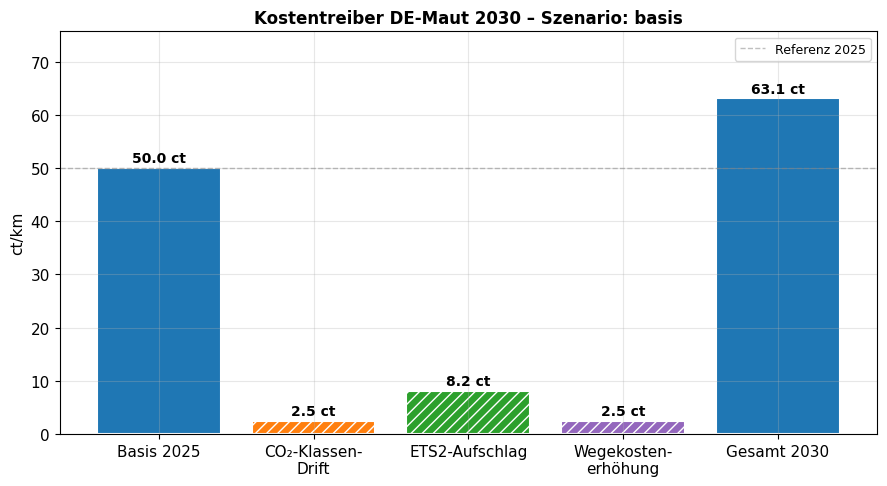


Zusammenfassung Basis-Szenario 2030:
  Basis 2025:         50.0 ct/km
  CO₂-Klassenautomatik: +2.5 ct/km
  ETS2 (ab 2027):     +8.2 ct/km
  Wegekostenerhöhung: +2.5 ct/km
  ─────────────────────────
  Gesamt 2030:        63.1 ct/km  (+26% vs. 2025)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# ABBILDUNG 2: Kostenzusammensetzung DE 2025 vs. 2030 (Basis)
# Zeigt, welcher Treiber wie viel des Anstiegs erklärt
# ─────────────────────────────────────────────────────────────────────────────
szenario = 'basis'
j2025 = MAUT_HISTORISCH[2025][0]

drift_2030  = co2_klassendrift(j2025, ANTEIL_CO2_TEILSATZ_DE, 2030)
ets2_2030   = ets2_aufschlag_ct_km(2030, szenario, faktor=1.0)
weg_2030    = WEGEKOSTEN_AUFSCHLAG_2028
gesamt_2030 = j2025 + drift_2030 + ets2_2030 + weg_2030

kategorien = ['Basis 2025', 'CO₂-Klassen-\nDrift', 'ETS2-Aufschlag', 'Wegekosten-\nerhöhung', 'Gesamt 2030']
werte      = [j2025, drift_2030, ets2_2030, weg_2030, gesamt_2030]
farben_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4']
muster     = ['', '///', '///', '///', '']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(kategorien, werte, color=farben_bar, hatch=muster, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, werte):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f} ct', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title(f'Kostentreiber DE-Maut 2030 – Szenario: {szenario}', fontsize=12, fontweight='bold')
ax.set_ylabel('ct/km')
ax.set_ylim(0, max(werte) * 1.2)
ax.axhline(y=j2025, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Referenz 2025')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('maut_kostentreiber_2030.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nZusammenfassung Basis-Szenario 2030:')
print(f'  Basis 2025:         {j2025:.1f} ct/km')
print(f'  CO₂-Klassenautomatik: +{drift_2030:.1f} ct/km')
print(f'  ETS2 (ab 2027):     +{ets2_2030:.1f} ct/km')
print(f'  Wegekostenerhöhung: +{weg_2030:.1f} ct/km')
print(f'  ─────────────────────────')
print(f'  Gesamt 2030:        {gesamt_2030:.1f} ct/km  (+{(gesamt_2030/j2025-1)*100:.0f}% vs. 2025)')

## 5. Sensitivitätsanalyse: ETS2-Preis als freier Parameter

Da der ETS2-Preis der größte Unsicherheitsfaktor ist, wird er hier systematisch variiert.

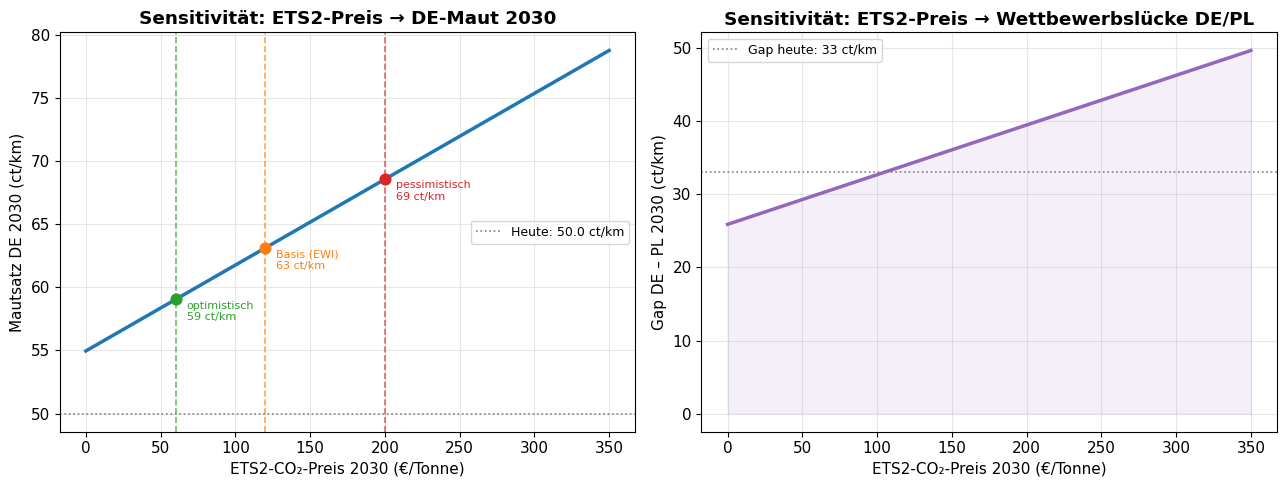

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SENSITIVITÄTSANALYSE: ETS2-Preis 2030 vs. Mautsatz DE
# ─────────────────────────────────────────────────────────────────────────────
ets2_preise = np.arange(0, 351, 10)  # €/Tonne, 0 bis 350

basis_2025 = MAUT_HISTORISCH[2025][0]
drift_fix  = co2_klassendrift(basis_2025, ANTEIL_CO2_TEILSATZ_DE, 2030)

maut_de_2030_sens = [
    basis_2025 + drift_fix + (EMISSIONEN_EURO6_G_KM * p / 10_000) + WEGEKOSTEN_AUFSCHLAG_2028
    for p in ets2_preise
]

# Gap vs. Polen (Basis PL 2030)
pl_basis_2030 = maut_pl(2030, 'basis')  # ohne ETS2-Variation
gap_sens = [m - pl_basis_2030 for m in maut_de_2030_sens]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Links: Mautsatz DE
ax1.plot(ets2_preise, maut_de_2030_sens, color='#1f77b4', linewidth=2.5)
for p_mark, label, col in [(60,'optimistisch','#2ca02c'), (120,'Basis (EWI)','#ff7f0e'), (200,'pessimistisch','#d62728')]:
    m_mark = basis_2025 + drift_fix + (EMISSIONEN_EURO6_G_KM * p_mark / 10_000) + WEGEKOSTEN_AUFSCHLAG_2028
    ax1.axvline(x=p_mark, color=col, linestyle='--', linewidth=1.2, alpha=0.7)
    ax1.scatter([p_mark], [m_mark], color=col, zorder=5, s=60)
    ax1.annotate(f'{label}\n{m_mark:.0f} ct/km', (p_mark, m_mark),
                 textcoords='offset points', xytext=(8, -15), fontsize=8, color=col)
ax1.axhline(y=basis_2025, color='gray', linestyle=':', linewidth=1.2, label=f'Heute: {basis_2025} ct/km')
ax1.set_xlabel('ETS2-CO₂-Preis 2030 (€/Tonne)')
ax1.set_ylabel('Mautsatz DE 2030 (ct/km)')
ax1.set_title('Sensitivität: ETS2-Preis → DE-Maut 2030', fontweight='bold')
ax1.legend(fontsize=9)

# Rechts: Gap DE – PL
ax2.plot(ets2_preise, gap_sens, color='#9467bd', linewidth=2.5)
ax2.fill_between(ets2_preise, gap_sens, alpha=0.1, color='#9467bd')
ax2.axhline(y=MAUT_HISTORISCH[2025][0]-MAUT_HISTORISCH[2025][1],
            color='gray', linestyle=':', linewidth=1.2, label='Gap heute: 33 ct/km')
ax2.set_xlabel('ETS2-CO₂-Preis 2030 (€/Tonne)')
ax2.set_ylabel('Gap DE – PL 2030 (ct/km)')
ax2.set_title('Sensitivität: ETS2-Preis → Wettbewerbslücke DE/PL', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('maut_sensitivitaet_ets2.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Wettbewerbsimplikation: Route Dresden → Warschau

Konkrete Kostenkalkulation für eine typische sächsische Musterroute:
**Dresden → Warschau** (ca. 620 km, davon ~340 km in DE, ~280 km in PL).

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# MUSTERROUTE: DRESDEN → WARSCHAU
# ─────────────────────────────────────────────────────────────────────────────

# Streckenlängen
KM_DE = 340   # km auf deutschem Mautnetz
KM_PL = 280   # km auf polnischem Mautnetz

print('=' * 60)
print('MUSTERROUTE: Dresden → Warschau')
print(f'  {KM_DE} km DE-Mautnetz + {KM_PL} km PL-Mautnetz')
print('=' * 60)

for szenario in ['optimistisch', 'basis', 'pessimistisch']:
    de25 = MAUT_HISTORISCH[2025][0]
    pl25 = MAUT_HISTORISCH[2025][1]
    de30 = maut_de(2030, szenario)
    pl30 = maut_pl(2030, szenario)

    # Kosten pro Tour
    kosten_de_2025 = (de25 * KM_DE + pl25 * KM_PL) / 100
    kosten_pl_2025 = pl25 * (KM_DE + KM_PL) / 100  # polnischer LKW zahlt überall PL-Satz
    # (Vereinfachung: polnischer LKW zahlt in DE dieselbe Maut wie DE-LKW)
    kosten_de_2030 = (de30 * KM_DE + pl30 * KM_PL) / 100
    kosten_pl_2030 = (de30 * KM_DE + pl30 * KM_PL) / 100  # Maut gleich für alle

    print(f'\nSzenario: {szenario.upper()}')
    print(f'  DE-Maut 2025: {de25:.1f} ct/km | 2030: {de30:.1f} ct/km (+{(de30/de25-1)*100:.0f}%)')
    print(f'  PL-Maut 2025: {pl25:.1f} ct/km | 2030: {pl30:.1f} ct/km (+{(pl30/pl25-1)*100:.0f}%)')
    print(f'  Mautkosten pro Tour 2025: {kosten_de_2025:.0f} €')
    print(f'  Mautkosten pro Tour 2030: {kosten_de_2030:.0f} € (+{(kosten_de_2030/kosten_de_2025-1)*100:.0f}%)')
    print(f'  Gap DE–PL 2030: {(de30-pl30):.1f} ct/km')

MUSTERROUTE: Dresden → Warschau
  340 km DE-Mautnetz + 280 km PL-Mautnetz

Szenario: OPTIMISTISCH
  DE-Maut 2025: 50.0 ct/km | 2030: 59.0 ct/km (+18%)
  PL-Maut 2025: 17.0 ct/km | 2030: 27.0 ct/km (+59%)
  Mautkosten pro Tour 2025: 218 €
  Mautkosten pro Tour 2030: 276 € (+27%)
  Gap DE–PL 2030: 32.0 ct/km

Szenario: BASIS
  DE-Maut 2025: 50.0 ct/km | 2030: 63.1 ct/km (+26%)
  PL-Maut 2025: 17.0 ct/km | 2030: 29.1 ct/km (+71%)
  Mautkosten pro Tour 2025: 218 €
  Mautkosten pro Tour 2030: 296 € (+36%)
  Gap DE–PL 2030: 34.1 ct/km

Szenario: PESSIMISTISCH
  DE-Maut 2025: 50.0 ct/km | 2030: 68.6 ct/km (+37%)
  PL-Maut 2025: 17.0 ct/km | 2030: 31.8 ct/km (+87%)
  Mautkosten pro Tour 2025: 218 €
  Mautkosten pro Tour 2030: 322 € (+48%)
  Gap DE–PL 2030: 36.8 ct/km


## 7. Ergebnistabelle & Export

Vollständige Ergebnistabelle für alle Szenarien und Jahre.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPORT
# ─────────────────────────────────────────────────────────────────────────────
df.to_csv('maut_szenarien_2030.csv', index=False, sep=';', decimal=',')
print('Ergebnistabelle exportiert: maut_szenarien_2030.csv')
print()

# Pivot-Ansicht: alle Szenarien 2025–2030
pivot_final = df[df['Jahr'] >= 2025].pivot_table(
    index='Jahr',
    columns='Szenario',
    values='DE (ct/km)'
).round(1)
pivot_final.columns.name = 'DE Maut (ct/km)'
print(pivot_final.to_string())
print()

print('Quellenverweise:')
print('  DE Mautsätze:  https://www.bmv.de/DE/Themen/Mobilitaet/Strasse/Strassenverkehr/Lkw-Maut/')
print('  PL Mautsätze:  https://etoll.gov.pl/de/e-toll-system/mautsaetze-und-zahlungen/')
print('  CZ Mautsätze:  https://myto.gov.cz/de')
print('  ETS2-Szenarien: https://www.ewi.uni-koeln.de')
print('  CO2-Klassen:   https://www.dkv-mobility.com/de/maut/maut-pro-land/deutschland/co2-maut/')

Ergebnistabelle exportiert: maut_szenarien_2030.csv

DE Maut (ct/km)  basis  optimistisch  pessimistisch
Jahr                                               
2025              50.0          50.0           50.0
2026              50.4          50.4           50.4
2027              57.0          54.0           59.7
2028              60.7          57.6           64.8
2029              61.9          58.4           66.7
2030              63.1          59.0           68.6

Quellenverweise:
  DE Mautsätze:  https://www.bmv.de/DE/Themen/Mobilitaet/Strasse/Strassenverkehr/Lkw-Maut/
  PL Mautsätze:  https://etoll.gov.pl/de/e-toll-system/mautsaetze-und-zahlungen/
  CZ Mautsätze:  https://myto.gov.cz/de
  ETS2-Szenarien: https://www.ewi.uni-koeln.de
  CO2-Klassen:   https://www.dkv-mobility.com/de/maut/maut-pro-land/deutschland/co2-maut/
